# Notebook 2: Feature Engineering
**Input:** `outputs/rba_cleaned.parquet` (from Notebook 1)  
**Output:** `outputs/rba_features.parquet`  

Feature groups created:
- **Temporal** — hour, day-of-week, month, is_weekend, is_night
- **Geo** — country/region/city frequency encoding
- **Device/Browser/OS** — label encoding and top-N grouping
- **Network** — ASN frequency encoding
- **User behaviour** — user login frequency, user-country combinations
- **RTT** — normalized, log-transformed

In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, warnings, time
warnings.filterwarnings('ignore')

OUTPUT_DIR = os.path.join(os.getcwd(), 'outputs')
clean_path = os.path.join(OUTPUT_DIR, 'rba_cleaned.parquet')

if not os.path.exists(clean_path):
    raise FileNotFoundError(f'Missing: {clean_path}\nRun Notebook 1 first.')
print(f'File found: {os.path.getsize(clean_path)/1e6:.1f} MB')

t0 = time.time()
df = pd.read_parquet(clean_path, engine='pyarrow')
print(f'Loaded in {time.time()-t0:.1f}s  |  shape: {df.shape}')
df.head(3)


File found: 47.1 MB
Loaded in 0.4s  |  shape: (1000000, 15)


,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,2020-02-03 12:46:25.828,-4324475583306591935,NaN,37.191.162.246,NO,Oslo County,Oslo,57963,Mozilla/5.0 (Android 6.0.99; Tablet; https://...,Chrome Mobile WebView 85.0.4183,Android 6.0.99,mobile,False,False,False
1,2020-02-03 12:46:52.905,-4324475583306591935,NaN,94.198.241.134,CZ,Hlavni mesto Praha,Prague,62160,Mozilla/5.0 (iPhone; CPU iPhone OS 11_2_6 lik...,Chrome Mobile WebView 85.0.4183,iOS 11.2.6,mobile,False,False,False
2,2020-02-03 12:46:55.455,9187119392009558735,NaN,10.0.183.79,RO,Arges,Curtea de Argeş,500372,Mozilla/5.0 (X11; CrOS armv7l 12105.100.0) Ap...,Chrome 69.0.3497.17.19,Chrome OS 12105.100.0,desktop,True,False,False


## 1. Temporal Features

In [31]:
ts = df['Login Timestamp']

df['hour']       = ts.dt.hour
df['dayofweek']  = ts.dt.dayofweek        # 0=Monday, 6=Sunday
df['month']      = ts.dt.month
df['day']        = ts.dt.day
df['is_weekend'] = (df['dayofweek'] >= 5).astype(int)
df['is_night']   = ((df['hour'] >= 22) | (df['hour'] < 6)).astype(int)

print('Temporal features added.')
print(df[['hour', 'dayofweek', 'month', 'is_weekend', 'is_night']].describe())

Temporal features added.
                 hour       dayofweek           month      is_weekend  \
count  1000000.000000  1000000.000000  1000000.000000  1000000.000000   
mean        12.220263        2.891040        6.377444        0.259222   
std          5.679444        1.982303        3.723848        0.438208   
min          0.000000        0.000000        1.000000        0.000000   
25%          8.000000        1.000000        3.000000        0.000000   
50%         12.000000        3.000000        6.000000        0.000000   
75%         17.000000        5.000000       10.000000        1.000000   
max         23.000000        6.000000       12.000000        1.000000   

             is_night  
count  1000000.000000  
mean         0.172374  
std          0.377705  
min          0.000000  
25%          0.000000  
50%          0.000000  
75%          0.000000  
max          1.000000  


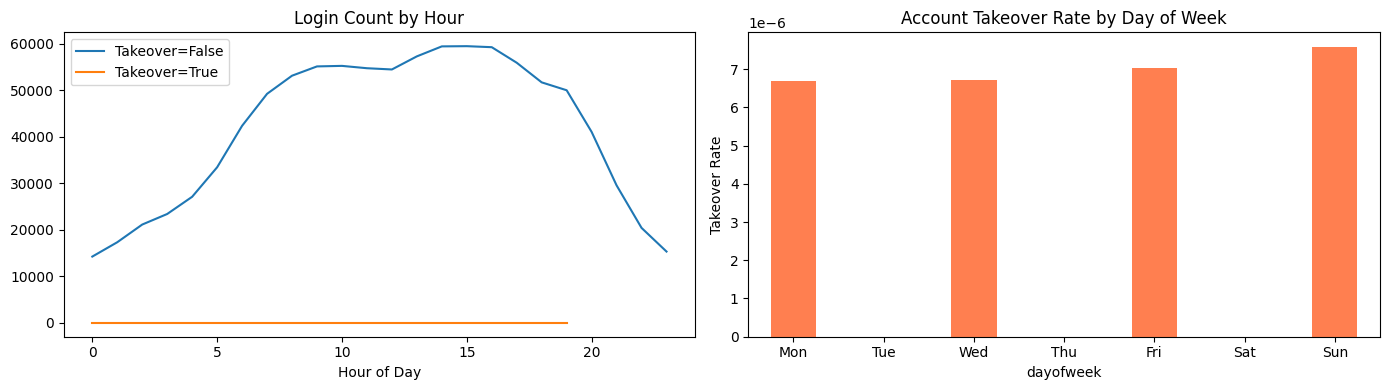

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Logins by hour split by Is Attack IP
for label, grp in df.groupby('Is Attack IP'):
    grp['hour'].value_counts().sort_index().plot(ax=axes[0],
        label=f'Attack IP={label}', linewidth=1.5)
axes[0].set_title('Login Count by Hour (split by Is Attack IP)')
axes[0].set_xlabel('Hour of Day')
axes[0].legend()

# Attack IP rate by day-of-week
days = ['Mon','Tue','Wed','Thu','Fri','Sat','Sun']
df.groupby('dayofweek')['Is Attack IP'].mean().plot(
    kind='bar', ax=axes[1], color='tomato')
axes[1].set_title('Attack IP Rate by Day of Week')
axes[1].set_xticklabels(days, rotation=0)
axes[1].set_ylabel('Attack IP Rate')

plt.tight_layout()
plt.show()


## 2. Geo Features — Frequency Encoding

In [33]:
def freq_encode(df, col, new_col):
    freq_map = df[col].value_counts(normalize=True).to_dict()
    df[new_col] = df[col].map(freq_map).fillna(0)
    return df

df = freq_encode(df, 'Country', 'country_freq')
df = freq_encode(df, 'Region',  'region_freq')
df = freq_encode(df, 'City',    'city_freq')

print('Geo frequency features added.')
print(df[['country_freq', 'region_freq', 'city_freq']].describe())

Geo frequency features added.
         country_freq     region_freq       city_freq
count  1000000.000000  1000000.000000  1000000.000000
mean         0.262593        0.218112        0.205618
std          0.167563        0.210006        0.215784
min          0.000001        0.000000        0.000000
25%          0.054077        0.015392        0.001800
50%          0.278001        0.073781        0.073513
75%          0.422239        0.449667        0.445555
max          0.422239        0.449667        0.445555


## 3. Network Feature — ASN Frequency Encoding

In [34]:
df = freq_encode(df, 'ASN', 'asn_freq')

# Top ASNs by attack rate
top_asn = (df.groupby('ASN')['Is Attack IP']
             .agg(['mean', 'count'])
             .query('count >= 100')
             .sort_values('mean', ascending=False)
             .head(15))
print('Top 15 ASNs by Attack IP rate (min 100 logins):')
print(top_asn)

Top 15 ASNs by Attack IP rate (min 100 logins):
            mean  count
ASN                    
197535  1.000000    147
500203  1.000000    297
57423   0.973832    535
500254  0.942911   1594
500021  0.920698   1261
22612   0.873112    331
63673   0.816054    299
398986  0.781367   9907
41944   0.624079    407
501404  0.620915    153
265355  0.566667    150
500039  0.539764   5432
207674  0.532212   2794
134674  0.469256    309
500055  0.430000    100


## 4. Device / Browser / OS Features

In [35]:
# Device type: label encode
device_map = {v: i for i, v in enumerate(df['Device Type'].value_counts().index)}
df['device_type_enc'] = df['Device Type'].map(device_map).fillna(-1).astype(int)

# Browser: keep top 20, rest → 'Other'
top_browsers = df['Browser Name and Version'].value_counts().nlargest(20).index
df['browser_group'] = df['Browser Name and Version'].where(
    df['Browser Name and Version'].isin(top_browsers), 'Other')
df = freq_encode(df, 'browser_group', 'browser_freq')

# OS: keep top 20, rest → 'Other'
top_os = df['OS Name and Version'].value_counts().nlargest(20).index
df['os_group'] = df['OS Name and Version'].where(
    df['OS Name and Version'].isin(top_os), 'Other')
df = freq_encode(df, 'os_group', 'os_freq')

print('Device/Browser/OS features added.')
print('Device type encoding:')
print(dict(sorted(device_map.items(), key=lambda x: x[1])))

Device/Browser/OS features added.
Device type encoding:
{'mobile': 0, 'desktop': 1, 'bot': 2, 'unknown': 3, 'tablet': 4}


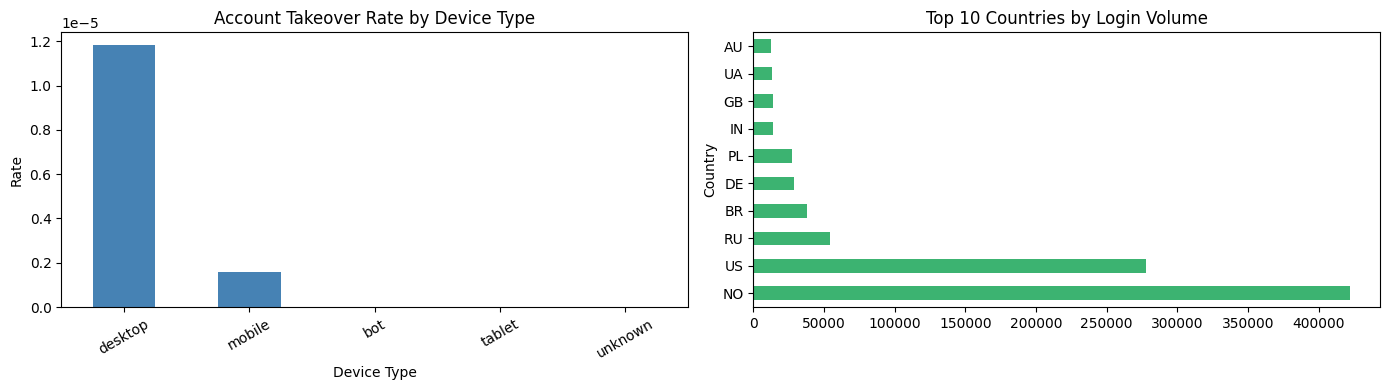

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Attack IP rate by device type
(df.groupby('Device Type')['Is Attack IP'].mean()
   .sort_values(ascending=False)
   .plot(kind='bar', ax=axes[0], color='tomato'))
axes[0].set_title('Attack IP Rate by Device Type')
axes[0].set_ylabel('Rate')
axes[0].tick_params(axis='x', rotation=30)

# Top 10 countries by login volume
(df['Country'].value_counts().head(10)
   .plot(kind='barh', ax=axes[1], color='mediumseagreen'))
axes[1].set_title('Top 10 Countries by Login Volume')

plt.tight_layout()
plt.show()


## 5. User Behaviour Features

In [37]:
# User login frequency
user_freq = df['User ID'].value_counts().to_dict()
df['user_login_freq'] = df['User ID'].map(user_freq)

# Number of distinct countries per user
user_country_cnt = df.groupby('User ID')['Country'].nunique().to_dict()
df['user_country_count'] = df['User ID'].map(user_country_cnt)

# Number of distinct IPs per user
user_ip_cnt = df.groupby('User ID')['IP Address'].nunique().to_dict()
df['user_ip_count'] = df['User ID'].map(user_ip_cnt)

print('User behaviour features added.')
print(df[['user_login_freq', 'user_country_count', 'user_ip_count']].describe())

User behaviour features added.
       user_login_freq  user_country_count   user_ip_count
count   1000000.000000      1000000.000000  1000000.000000
mean     201001.274792           92.014689    73316.232913
std      222956.876713          100.952312    81327.512691
min           1.000000            1.000000        1.000000
25%           1.000000            1.000000        1.000000
50%           3.000000            1.000000        2.000000
75%      448325.000000          204.000000   163532.000000
max      448325.000000          204.000000   163532.000000


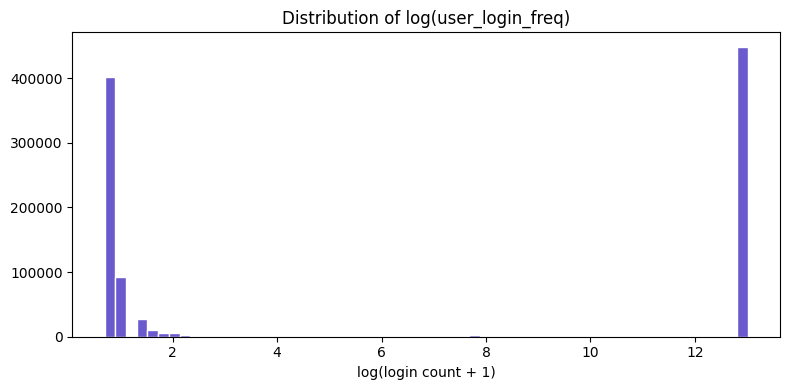

In [38]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(np.log1p(df['user_login_freq']), bins=60, color='slateblue', edgecolor='white')
ax.set_title('Distribution of log(user_login_freq)')
ax.set_xlabel('log(login count + 1)')
plt.tight_layout()
plt.show()

## 6. RTT Transformation

In [39]:
df['rtt_log1p'] = np.log1p(df['Round-Trip Time [ms]'].clip(lower=0))

# Z-score normalise
rtt_mean = df['rtt_log1p'].mean()
rtt_std  = df['rtt_log1p'].std()
df['rtt_zscore'] = (df['rtt_log1p'] - rtt_mean) / rtt_std

print(f'RTT log+zscore: mean={rtt_mean:.3f}, std={rtt_std:.3f}')
print(df[['Round-Trip Time [ms]', 'rtt_log1p', 'rtt_zscore']].describe())

RTT log+zscore: mean=6.226, std=0.853
       Round-Trip Time [ms]     rtt_log1p    rtt_zscore
count          40563.000000  40563.000000  4.056300e+04
mean             672.323521      6.225518 -2.235171e-16
std             1189.353348      0.853245  1.000000e+00
min                8.000000      2.197225 -4.721144e+00
25%              471.000000      6.156979 -8.032790e-02
50%              538.000000      6.289716  7.523885e-02
75%              678.000000      6.520621  3.458592e-01
max            86587.000000     11.368917  6.028042e+00


## 6b. Security Behaviour Features

These features directly capture credential-stuffing and account-takeover patterns by summarising
past activity per IP and per user. Computed from the same 1M-row sample — no external data needed.


In [40]:
# Sort by timestamp so lookbacks are temporally valid
df = df.sort_values('Login Timestamp').reset_index(drop=True)

# --- Per-IP aggregate features ---
ip_grp = df.groupby('IP Address')

# Total logins from the same IP
df['ip_login_count'] = df['IP Address'].map(ip_grp['Login Successful'].count())

# Failed logins from the same IP (aggregate)
ip_fail = ip_grp['Login Successful'].apply(lambda s: (~s.astype(bool)).sum()).to_dict()
df['ip_fail_count'] = df['IP Address'].map(ip_fail)

# Failure rate for the IP
df['ip_fail_rate'] = df['ip_fail_count'] / df['ip_login_count'].clip(lower=1)

# Distinct users seen from the same IP (many users → suspicious)
df['ip_user_count'] = df['IP Address'].map(ip_grp['User ID'].nunique())

# --- Cumulative previous counts per IP (temporally valid, no future leakage) ---
# Number of prior login attempts from this IP (0 = first time seen)
df['ip_prev_login_count'] = df.groupby('IP Address').cumcount()

# Binary fail flag used for both IP and user cumulative fail counts
df['_fail'] = (~df['Login Successful'].astype(bool)).astype(int)

# Number of prior failed attempts from this IP (excludes current row)
df['ip_prev_fail_count'] = df.groupby('IP Address')['_fail'].transform(
    lambda s: s.cumsum() - s
)

print('Per-IP security features added:')
print(df[['ip_login_count', 'ip_fail_count', 'ip_fail_rate',
          'ip_user_count', 'ip_prev_login_count', 'ip_prev_fail_count']].describe())


Per-IP security features added:
       ip_login_count   ip_fail_count    ip_fail_rate   ip_user_count  \
count  1000000.000000  1000000.000000  1000000.000000  1000000.000000   
mean       629.716200      620.000683        0.599152       14.990455   
std       2256.132444     2257.904835        0.398660       42.500007   
min          1.000000        0.000000        0.000000        1.000000   
25%          1.000000        1.000000        0.142857        1.000000   
50%          4.000000        2.000000        0.733333        1.000000   
75%         90.000000       67.000000        1.000000       16.000000   
max      14260.000000    14260.000000        1.000000      956.000000   

       ip_prev_login_count  ip_prev_fail_count  
count       1000000.000000      1000000.000000  
mean            314.358100          309.527691  
std            1315.202022         1315.820594  
min               0.000000            0.000000  
25%               0.000000            0.000000  
50%             

In [41]:
# --- Per-user aggregate features ---
user_grp = df.groupby('User ID')

# Historical login success rate per user (aggregate)
user_success = user_grp['Login Successful'].mean().to_dict()
df['user_prev_success_rate'] = df['User ID'].map(user_success)

# Time since previous login for the same user (seconds), -1 if first login
df['_prev_ts'] = df.groupby('User ID')['Login Timestamp'].shift(1)
df['user_time_since_last_login'] = (
    df['Login Timestamp'] - df['_prev_ts']
).dt.total_seconds().fillna(-1).clip(lower=-1)
df.drop(columns=['_prev_ts'], inplace=True)

# --- Cumulative previous counts per user (temporally valid) ---
# Number of prior logins by this user (0 = first login)
df['user_prev_login_count'] = df.groupby('User ID').cumcount()

# Number of prior failed logins by this user (reuses _fail from IP cell)
df['user_prev_fail_count'] = df.groupby('User ID')['_fail'].transform(
    lambda s: s.cumsum() - s
)
df.drop(columns=['_fail'], inplace=True)

# --- Context-change features (1 = changed from previous login by same user) ---
# Country changed since previous login
df['_prev_country'] = df.groupby('User ID')['Country'].shift(1)
df['country_changed'] = (
    (df['Country'] != df['_prev_country']) & df['_prev_country'].notna()
).astype(int)
df.drop(columns=['_prev_country'], inplace=True)

# Device type changed since previous login
df['_prev_device'] = df.groupby('User ID')['Device Type'].shift(1)
df['device_changed'] = (
    (df['Device Type'] != df['_prev_device']) & df['_prev_device'].notna()
).astype(int)
df.drop(columns=['_prev_device'], inplace=True)

print('Per-user security features added:')
print(df[['user_prev_success_rate', 'user_time_since_last_login',
          'user_prev_login_count', 'user_prev_fail_count',
          'country_changed', 'device_changed']].describe())


Per-user security features added:
       user_prev_success_rate  user_time_since_last_login  \
count          1000000.000000                1.000000e+06   
mean                 0.400848                5.372567e+05   
std                  0.481050                2.703031e+06   
min                  0.000000               -1.000000e+00   
25%                  0.000000               -1.000000e+00   
50%                  0.000000                4.874000e+00   
75%                  1.000000                6.802900e+01   
max                  1.000000                3.343596e+07   

       user_prev_login_count  user_prev_fail_count  country_changed  \
count         1000000.000000        1000000.000000   1000000.000000   
mean           100500.137396         100499.959498         0.338112   
std            141197.446968         141197.573576         0.473067   
min                 0.000000              0.000000         0.000000   
25%                 0.000000              0.000000         0.

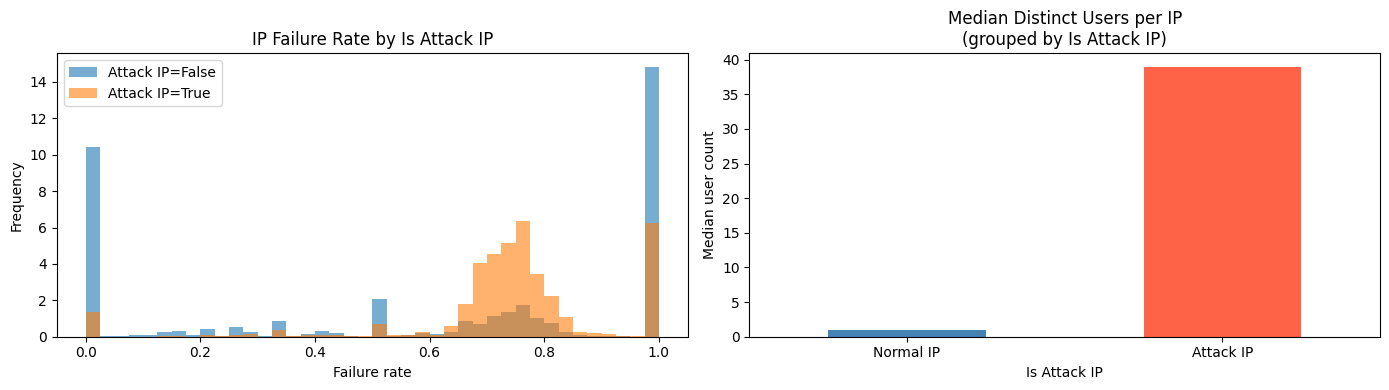

In [42]:
# Visualise: IP failure rate and user count split by Is Attack IP
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for label, grp in df.groupby('Is Attack IP'):
    grp['ip_fail_rate'].clip(0, 1).plot.hist(bins=40, alpha=0.6,
        label=f'Attack IP={label}', ax=axes[0], density=True)
axes[0].set_title('IP Failure Rate by Is Attack IP')
axes[0].set_xlabel('Failure rate')
axes[0].legend()

df.groupby('Is Attack IP')['ip_user_count'].median().plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Median Distinct Users per IP\n(grouped by Is Attack IP)')
axes[1].set_xticklabels(['Normal IP', 'Attack IP'], rotation=0)
axes[1].set_ylabel('Median user count')

plt.tight_layout()
plt.show()


## 7. Select Final Feature Set

In [43]:
FEATURE_COLS = [
    # Temporal
    'hour', 'dayofweek', 'month', 'is_weekend', 'is_night',
    # Network / Geo
    'country_freq', 'region_freq', 'city_freq', 'asn_freq',
    # Device / Browser / OS
    'device_type_enc', 'browser_freq', 'os_freq',
    # RTT
    'rtt_log1p', 'rtt_zscore',
    # User behaviour (aggregate)
    'user_login_freq', 'user_country_count', 'user_ip_count',
    # Security behaviour — aggregate per IP
    'ip_login_count', 'ip_fail_count', 'ip_fail_rate', 'ip_user_count',
    # Security behaviour — user history (aggregate)
    'user_prev_success_rate',
    # Cumulative previous counts (temporally valid, no future leakage)
    'ip_prev_login_count', 'ip_prev_fail_count',
    'user_prev_login_count', 'user_prev_fail_count',
    # Time gap
    'user_time_since_last_login',
    # Context-change flags
    'country_changed', 'device_changed',
]

TARGET_COLS = ['Is Account Takeover', 'Is Attack IP', 'Login Successful']

df_features = df[FEATURE_COLS + TARGET_COLS].copy()
print(f'Feature matrix shape: {df_features.shape}')
print(f'Total features: {len(FEATURE_COLS)}')
df_features.head(3)


Feature matrix shape: (1000000, 32)
Total features: 29


,hour,dayofweek,month,is_weekend,is_night,country_freq,region_freq,city_freq,asn_freq,device_type_enc,...,ip_prev_login_count,ip_prev_fail_count,user_prev_login_count,user_prev_fail_count,user_time_since_last_login,country_changed,device_changed,Is Account Takeover,Is Attack IP,Login Successful
0,12,0,2,0,0,0.422239,0.073781,0.073513,0.007960,0,...,0,0,0,0,-1.000,0,0,False,False,False
1,12,0,2,0,0,0.003854,0.001255,0.001250,0.000628,0,...,0,0,1,1,27.077,1,0,False,False,False
2,12,0,2,0,0,0.003907,0.000030,0.000003,0.000020,1,...,0,0,0,0,-1.000,0,0,False,False,True


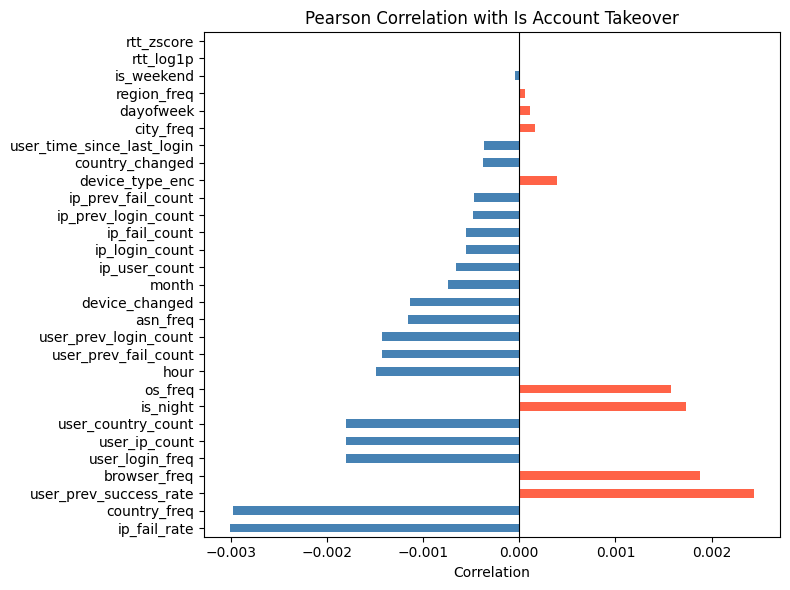

In [ ]:
# Correlation heatmap (features vs primary target: Is Attack IP)
corr = df_features[FEATURE_COLS + ['Is Attack IP']].corr()
attack_corr = corr['Is Attack IP'].drop('Is Attack IP').sort_values(key=abs, ascending=False)

fig, ax = plt.subplots(figsize=(8, 9))
attack_corr.plot(kind='barh', ax=ax, color=[('tomato' if v > 0 else 'steelblue') for v in attack_corr])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Pearson Correlation with Is Attack IP (primary target)')
ax.set_xlabel('Correlation')
plt.tight_layout()
plt.show()


## 8. Save Feature Matrix

In [45]:
feat_path = os.path.join(OUTPUT_DIR, 'rba_features.parquet')
df_features.to_parquet(feat_path, index=False, engine='pyarrow')
print(f'Feature matrix saved: {feat_path}')
print(f'File size: {os.path.getsize(feat_path)/1e6:.1f} MB')

# Save the feature column list for use in later notebooks
import json
meta = {'feature_cols': FEATURE_COLS, 'target_cols': TARGET_COLS}
meta_path = os.path.join(OUTPUT_DIR, 'feature_meta.json')
with open(meta_path, 'w') as f:
    json.dump(meta, f, indent=2)
print(f'Feature metadata saved: {meta_path}')


Feature matrix saved: c:\Users\ruchi\Downloads\rba-dataset.csv\outputs\rba_features.parquet
File size: 23.4 MB
Feature metadata saved: c:\Users\ruchi\Downloads\rba-dataset.csv\outputs\feature_meta.json


## Summary

| Feature Group | Features Created | Count |
|---------------|-----------------|-------|
| Temporal | hour, dayofweek, month, is_weekend, is_night | 5 |
| Geo / Network | country_freq, region_freq, city_freq, asn_freq | 4 |
| Device / Browser / OS | device_type_enc, browser_freq, os_freq | 3 |
| RTT | rtt_log1p, rtt_zscore | 2 |
| User behaviour (aggregate) | user_login_freq, user_country_count, user_ip_count | 3 |
| IP security (aggregate) | ip_login_count, ip_fail_count, ip_fail_rate, ip_user_count | 4 |
| User security (aggregate) | user_prev_success_rate | 1 |
| Cumulative prev. counts (temporally valid) | ip_prev_login_count, ip_prev_fail_count, user_prev_login_count, user_prev_fail_count | 4 |
| Time gap | user_time_since_last_login | 1 |
| Context-change flags | country_changed, device_changed | 2 |

**Total features: 29**

➜ **Next: Notebook 3 — Baseline + Logistic Regression + Random Forest**
